In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Step 1: Loading Dataset...
Step 2: Preprocessing Text...
Step 3: Encoding Labels and Tokenizing...

Training RNN Model...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4356 - loss: 1.0416 - val_accuracy: 0.6360 - val_loss: 0.8063
Epoch 2/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7480 - loss: 0.6361 - val_accuracy: 0.6169 - val_loss: 0.8702
Epoch 3/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8865 - loss: 0.3413 - val_accuracy: 0.5514 - val_loss: 1.1802
Epoch 4/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9427 - loss: 0.1822 - val_accuracy: 0.6056 - val_loss: 1.2280
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6456 - loss: 0.8024
RNN Test Accuracy: 0.6410

Training LSTM Model...
Epoch 1/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.4970 - loss: 0.9806 - val_accuracy: 0.6893 - val_loss: 0.7280
Epoch 2/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.7552 - loss: 0.6099 - val_accuracy: 0.7079 - val_loss: 0.7032
Epoch 3/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.8228 - loss: 0.4720 - val_accuracy: 0.6915

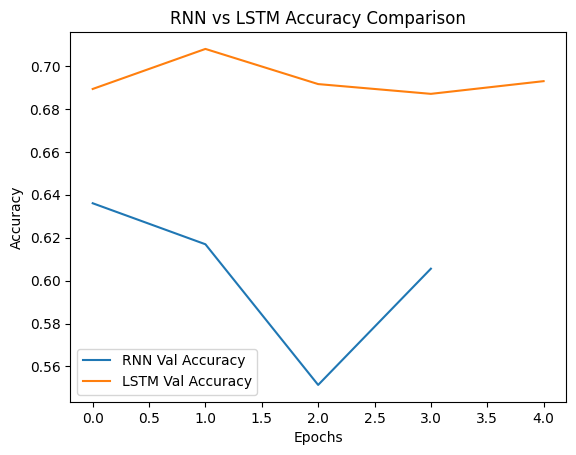


Final Comparison:
✅ LSTM is the better model
🔥 DONE! Best model saved as 'best_sentiment_model.h5'


In [3]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# =========================
# Step 1: Load Dataset
# =========================
print("Step 1: Loading Dataset...")
file_path = r"/kaggle/input/datasets/nucklehead09/dataanalysis/Tweets.csv"
df = pd.read_csv(file_path)

# =========================
# Step 2: Preprocess Text
# =========================
print("Step 2: Preprocessing Text...")

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.strip() != '']

# =========================
# Step 3: Encoding + Tokenizing
# =========================
print("Step 3: Encoding Labels and Tokenizing...")

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=max_len)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# Save tokenizer + encoder
# =========================
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle)

with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(label_encoder, handle)

# =========================
# Early Stopping
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# =========================
# Step 4: RNN Model
# =========================
print("\nTraining RNN Model...")

rnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test)
print(f"RNN Test Accuracy: {rnn_acc:.4f}")

# =========================
# Step 5: LSTM Model
# =========================
print("\nTraining LSTM Model...")

lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)
print(f"LSTM Test Accuracy: {lstm_acc:.4f}")

# =========================
# Step 6: Plot Accuracy Graph
# =========================
plt.figure()

plt.plot(rnn_history.history['val_accuracy'], label='RNN Val Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Val Accuracy')

plt.title("RNN vs LSTM Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# =========================
# Step 7: Compare Models
# =========================
print("\nFinal Comparison:")

if lstm_acc > rnn_acc:
    print("✅ LSTM is the better model")
    best_model = lstm_model
else:
    print("✅ RNN is the better model")
    best_model = rnn_model

# =========================
# Step 8: Save Best Model
# =========================
best_model.save("best_sentiment_model.h5")

print("🔥 DONE! Best model saved as 'best_sentiment_model.h5'")